1. Генерация данных  - косяк

#Импорт библиотек

In [ ]:
#import math
import numpy as np
from numpy.random import normal

import matplotlib.pyplot as pl
from numpy.random import multivariate_normal

In [ ]:
!pip install filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=fa9907a534ddfbb4e62b1671f5aceb25dd70a63cd037df830e272a9f495a61bd
  Stored in directory: /root/.cache/pip/wheels/12/dc/3c/e12983eac132d00f82a20c6cbe7b42ce6e96190ef8fa2d15e1
Successfully built filterpy


In [ ]:
import filterpy.kalman
import filterpy.common

#Генерация данных

Начальное состояние х0:
[[0.09079562]
 [0.08949509]
 [0.93352493]]
0.9335249270729884


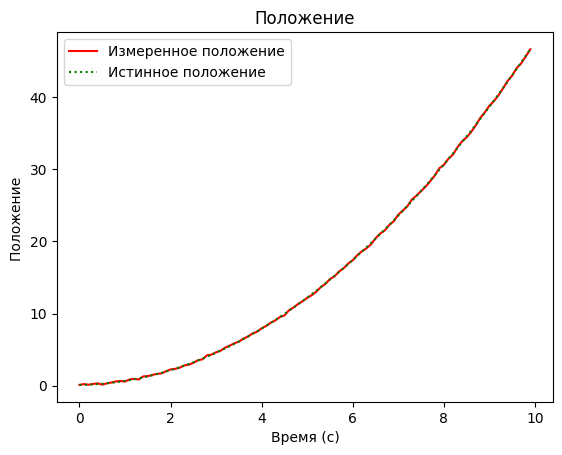

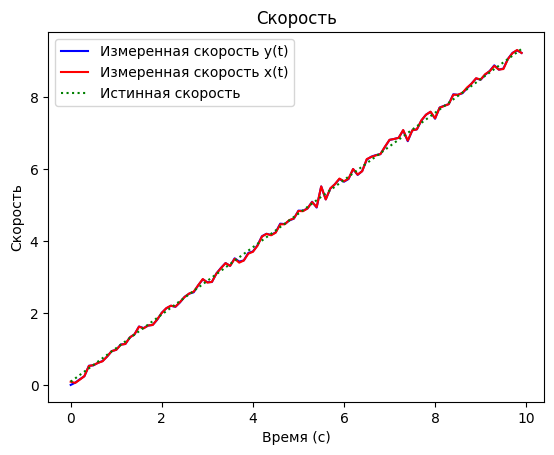

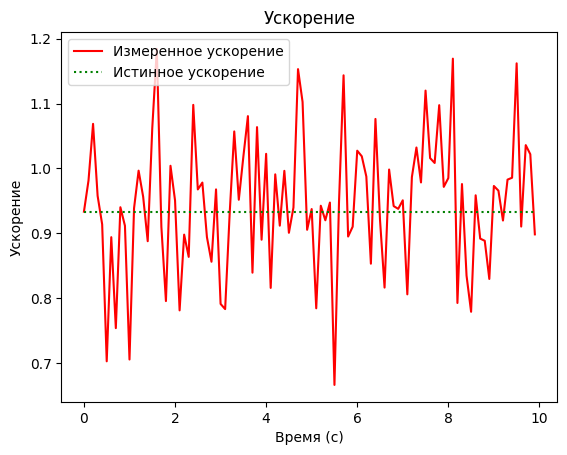

In [ ]:
# Параметры
n = 100
n_test = n // 3
d_t = 0.1
Q = np.array([[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]])  # шум процесса
R = 0.01  # Шум измерения

# Инициализация
x01 = multivariate_normal([0, 0, 1], Q, 1).T  # Начальное состояние
true_xk = np.zeros((n, 3))  # Истинные значения состояния
true_xk[0] = x01.T
x_model = np.zeros((3, n))
x_model[0][0] = x01[0][0]
x_model[1][0] = x01[1][0]
x_model[2][0] = x01[2][0]

print("Начальное состояние х0:")
print(x01)


#y_true = np.zeros((n, 1))  # Истинные значения (вторая компонента)
y_model = np.zeros((n, 1))  # Измеренные значения

# Матрица перехода
T = np.array([[1, d_t, (d_t ** 2) / 2], [0, 1, d_t], [0, 0, 1]])


# Генерация данных
for i in range(n - 1):
    w1 = multivariate_normal([0, 0, 0], Q, 1).T  # Шум процесса
    v1 = np.random.normal(0, R, 1)  # Шум измерения

    # Истинное значение (без шума измерения)
    true_xk[i + 1] = np.dot(T, true_xk[i].T).T
    if i==0:
      print(true_xk[i + 1][2])

    # Измеренное значение (с шумом измерения)
    cur_xk = np.reshape(true_xk[i + 1], (3,1)) + w1

    x_model[0][i+1] = cur_xk[0][0]
    x_model[1][i+1] = cur_xk[1][0]
    x_model[2][i+1] = cur_xk[2][0]

    y_model[i+1][0] = cur_xk[1][0] + v1[0]  # Добавляем шум измерения


# Время
time = np.array([i * d_t for i in range(n)])

true_xk = true_xk.T
# Визуализация
pl.plot(time, x_model[0], label="Измеренное положение", color="r")
pl.plot(time, true_xk[0], label="Истинное положение", color="g", linestyle="dotted")
pl.title("Положение")
pl.xlabel("Время (с)")
pl.ylabel("Положение ")
pl.legend()
pl.show()

# Визуализация
pl.plot(time, y_model, label="Измеренная скорость y(t)", color="b")
pl.plot(time, x_model[1], label="Измеренная скорость x(t)", color="r")
pl.plot(time, true_xk[1], label="Истинная скорость", color="g", linestyle="dotted")
pl.title("Скорость")
pl.xlabel("Время (с)")
pl.ylabel("Скорость")
pl.legend()
pl.show()

# Визуализация
pl.plot(time, x_model[2], label="Измеренное ускорение", color="r")
pl.plot(time, true_xk[2], label="Истинное ускорение", color="g", linestyle="dotted")
pl.title("Ускорение")
pl.xlabel("Время (с)")
pl.ylabel("Ускорение")
pl.legend()
pl.show()

#Deep Seek

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from filterpy.kalman import ExtendedKalmanFilter

class ElmanEKF(nn.Module):
    def __init__(self, input_size=1, hidden_size=10, output_size=1):
        super(ElmanEKF, self).__init__()
        # Elman Network components
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)

        # EKF initialization
        self.ekf = ExtendedKalmanFilter(dim_x=hidden_size, dim_z=output_size)
        self._init_ekf_params(hidden_size)

    def _init_ekf_params(self, hidden_size):
        """Initialize EKF parameters"""
        self.ekf.x = np.zeros(hidden_size)  # Initial state
        self.ekf.P = np.eye(hidden_size)    # Initial covariance
        self.ekf.R = 0.1 * np.eye(1)        # Measurement noise
        self.ekf.Q = 0.01 * np.eye(hidden_size)  # Process noise

    def forward(self, x, apply_ekf=True):
        # Elman network forward pass
        out, hidden = self.rnn(x)
        predictions = self.fc(out)

        if apply_ekf and self.training:
            # Конвертируем данные для EKF
            hidden_np = hidden.squeeze(0).detach().numpy()  # [hidden_size]
            pred_np = predictions[:,-1].detach().numpy()    # [output_size]

            # 1. Predict Step: используем hidden_np как прогнозируемое состояние
            self.ekf.x = hidden_np  # Важно: обновляем состояние EKF

            # 2. Update Step с передачей состояния
            self.ekf.predict_update(
                z=pred_np,
                HJacobian=self.h_jacobian,
                Hx=self.hx_function
            )

            # Корректируем скрытое состояние RNN
            corrected_hidden = torch.tensor(self.ekf.x,
                                          dtype=torch.float32).unsqueeze(0)
            out, _ = self.rnn(x[:,-1:], corrected_hidden)
            predictions = self.fc(out)

        return predictions

    def hx_function(self, x):
        """Measurement function for EKF"""
        with torch.no_grad():
            hidden = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
            return self.fc(hidden).numpy()

    def h_jacobian(self, x):
        """Jacobian of measurement function"""
        with torch.no_grad():
            hidden = torch.tensor(x, dtype=torch.float32).requires_grad_(True)
            output = self.fc(hidden.unsqueeze(0))
            jacobian = torch.zeros(output.shape[-1], hidden.shape[-1])

            for i in range(output.shape[-1]):
                grad_outputs = torch.zeros_like(output)
                grad_outputs[0,i] = 1.0
                grad = torch.autograd.grad(output, hidden,
                                         grad_outputs=grad_outputs,
                                         retain_graph=True)[0]
                jacobian[i,:] = grad
            return jacobian.numpy()

# Training procedure
def train_model(model, dataloader, epochs=100):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        for batch_x, batch_y in dataloader:
            optimizer.zero_grad()

            # Forward pass with EKF correction
            outputs = model(batch_x)

            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

In [ ]:
# Example usage
if __name__ == "__main__":
    # Generate synthetic process data
    time_steps = 1000
    t = np.linspace(0, 10, time_steps)
    process_data = np.sin(t) + 0.1*np.random.normal(size=time_steps)

    # Prepare dataset
    seq_length = 10
    X = []
    y = []
    for i in range(len(process_data)-seq_length):
        X.append(process_data[i:i+seq_length])
        y.append(process_data[i+1:i+seq_length+1])

    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    # Initialize model
    model = ElmanEKF(input_size=1, hidden_size=10, output_size=1)

    # Train
    from torch.utils.data import DataLoader, TensorDataset
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    train_model(model, dataloader)

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [ ]:
class EKFCorrectedRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=10, output_size=1):
        super(EKFCorrectedRNN, self).__init__()

        # RNN компоненты
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)

        # EKF параметры как обучаемые тензоры
        self.register_buffer('P', torch.eye(hidden_size))  # Ковариация состояния
        self.register_buffer('R', 0.1 * torch.eye(output_size))  # Шум измерений
        self.register_buffer('Q', 0.01 * torch.eye(hidden_size))  # Шум процесса

    def ekf_update(self, hidden, prediction):
        """Дифференцируемая версия EKF update"""
        # Вычисляем якобиан через torch.autograd.functional
        H = F.jacobian(
            lambda h: self.fc(h.unsqueeze(0)).squeeze(0),
            hidden,
            create_graph=True  # Для сохранения графа вычислений
        ).squeeze()

        # Калмановский коэффициент (K)
        S = torch.mm(H, torch.mm(self.P, H.t())) + self.R
        K = torch.mm(torch.mm(self.P, H.t()), torch.inverse(S))

         # Коррекция состояния
        hx = self.fc(hidden.unsqueeze(0)).squeeze(0)
        corrected_hidden = hidden + torch.mm(K, (prediction - hx).unsqueeze(-1)).squeeze()

        # Коррекция
        #innovation = prediction - hx
        #corrected_hidden = hidden + torch.mm(K, innovation.unsqueeze(-1)).squeeze()

        # Обновление ковариации
        I_KH = torch.eye(hidden.size(0)) - torch.mm(K, H)
        self.P = torch.mm(I_KH, self.P)

        return corrected_hidden

    def forward(self, x, apply_ekf=True):
        # Обычный forward pass
        out, hidden = self.rnn(x)
        predictions = self.fc(out)

        if apply_ekf:
            # Применяем EKF к последнему скрытому состоянию
            last_hidden = hidden.squeeze(0)
            last_pred = predictions[:, -1]

            # Дифференцируемая коррекция
            corrected_hidden = self.ekf_update(last_hidden, last_pred)

            # Обновляем только последний шаг
            out, _ = self.rnn(x[:, -1:], corrected_hidden.unsqueeze(0))
            predictions = torch.cat([
                predictions[:, :-1],
                self.fc(out)
            ], dim=1)

        return predictions

# Обучение остается стандартным
def train_model(model, dataloader, epochs=100):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in dataloader:
            optimizer.zero_grad()
            outputs = model(batch_x, apply_ekf=True)  # EKF включен при обучении
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')


In [ ]:
import torch.autograd.functional as F

In [ ]:
# Example usage
if __name__ == "__main__":
    # Generate synthetic process data
    time_steps = 1000
    t = np.linspace(0, 10, time_steps)
    process_data = np.sin(t) + 0.1*np.random.normal(size=time_steps)

    # Prepare dataset
    seq_length = 10
    X = []
    y = []
    for i in range(len(process_data)-seq_length):
        X.append(process_data[i:i+seq_length])
        y.append(process_data[i+1:i+seq_length+1])

    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    # Initialize model
    model = EKFCorrectedRNN(input_size=1, hidden_size=10, output_size=1)

    # Train
    from torch.utils.data import DataLoader, TensorDataset
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    train_model(model, dataloader)

RuntimeError: t() expects a tensor with <= 2 dimensions, but self is 3D

#Состояния фильтра(KF)

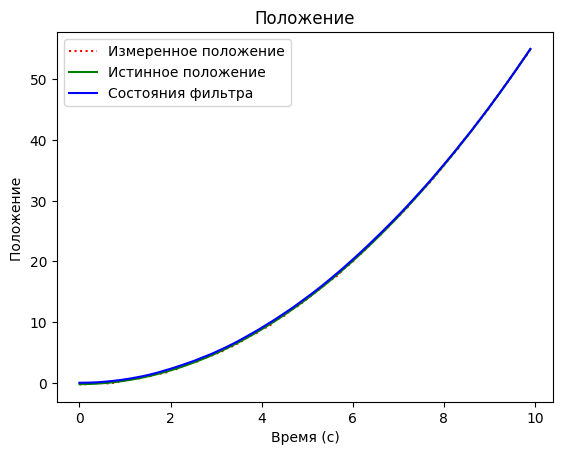

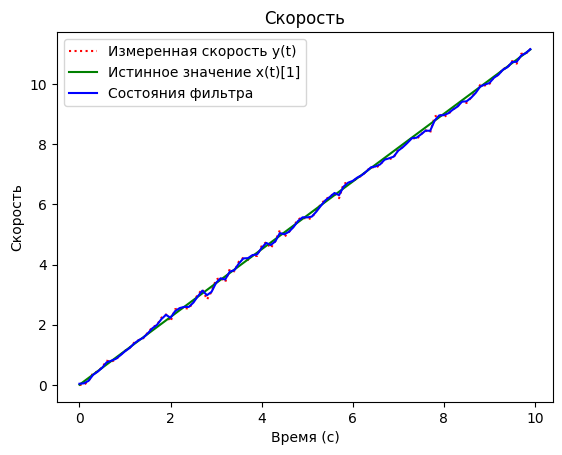

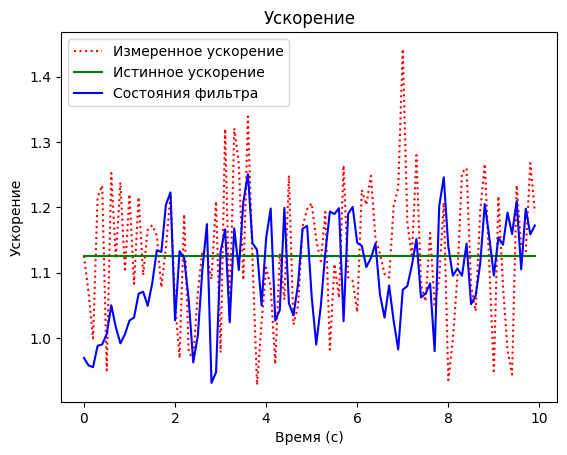

In [ ]:
dt = 0.1                     # Шаг времени
measurementSigma = 0.1          # Среднеквадратичное отклонение датчика
processNoise = 1e-4             # Погрешность модели

# Моделирование данных датчиков
#trajectory, measurement = simulateSensor(1000, measurementSigma, dt)

# Создаём объект KalmanFilter
filter = filterpy.kalman.KalmanFilter(dim_x=3,      # Размер вектора стостояния
                                     dim_z=1)      # Размер вектора измерений

# F - матрица процесса - размер dim_x на dim_x - 3х3
filter.F = np.array([ [1.0,   dt,     (dt**2)/2],
                     [0,   1.0,    dt],
                     [0,   0,      1.0]])


# Матрица наблюдения - dim_z на dim_x - 1x3
filter.H = np.array([[0.0, 1.0, 0.0]])

# Ковариационная матрица ошибки модели
#filter.Q = filterpy.common.Q_discrete_white_noise(dim=3, dt=dt, var= 0.01) #var=processNoiseVariance
filter.Q = np.array([[0.01, 0.0,  0.0],
                    [0.0,  0.01, 0.0],
                    [0.0,  0.0,  0.01]])

# Ковариационная матрица ошибки измерения - 1х1
#filter.R = np.random.normal(0, 0.01, 1)[0]
filter.R = np.array([[measurementSigma*measurementSigma]])


# Начальное состояние.
filter.x = np.random.normal([ 0, 0, 1], 0.01, 3)

# Ковариационная матрица для начального состояния
filter.P = np.array([[0.01, 0.0,  0.0],
                    [0.0,  0.01, 0.0],
                    [0.0,  0.0,  0.01]])

filteredState = []
stateCovarianceHistory = []

# Обработка данных
for i in range(0, len(y_model)):
   z = [y_model[i][0]]                      # Вектор измерений
   filter.predict()                            # Этап предсказания
   filter.update(z)                            # Этап коррекции

   filteredState.append(filter.x)
   stateCovarianceHistory.append(filter.P)

filteredState = np.array(filteredState)
stateCovarianceHistory = np.array(stateCovarianceHistory)



# Визуализация
pl.plot(time, x_model[0], label="Измеренное положение", color="r",  linestyle="dotted")
pl.plot(time, true_xk[0], label="Истинное положение", color="g")
pl.plot(time, filteredState[:, 0], label="Состояния фильтра", color="b")
pl.title("Положение")
pl.xlabel("Время (с)")
pl.ylabel("Положение ")
pl.legend()
pl.show()

# Визуализация
pl.plot(time, y_model, label="Измеренная скорость y(t)", color="r",  linestyle="dotted")
pl.plot(time, true_xk[1], label="Истинное значение x(t)[1]", color="g")
pl.plot(time, filteredState[:, 1], label="Состояния фильтра", color="b")
pl.title("Скорость")
pl.xlabel("Время (с)")
pl.ylabel("Скорость")
pl.legend()
pl.show()

# Визуализация
pl.plot(time, x_model[2], label="Измеренное ускорение", color="r",  linestyle="dotted")
pl.plot(time, true_xk[2], label="Истинное ускорение", color="g")
pl.plot(time, filteredState[:, 2], label="Состояния фильтра", color="b")
pl.title("Ускорение")
pl.xlabel("Время (с)")
pl.ylabel("Ускорение")
pl.legend()
pl.show()

In [ ]:
stateCovarianceHistory.shape

(50, 3, 3)

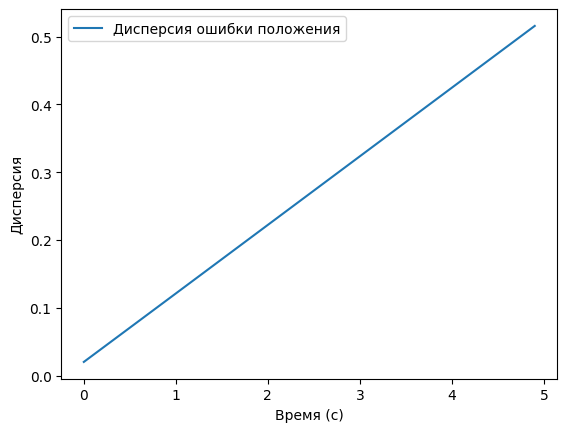

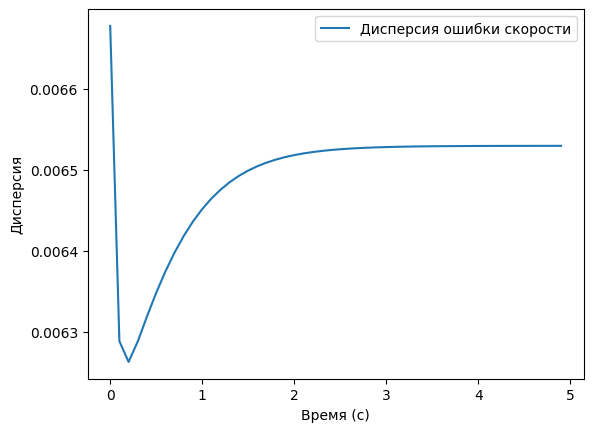

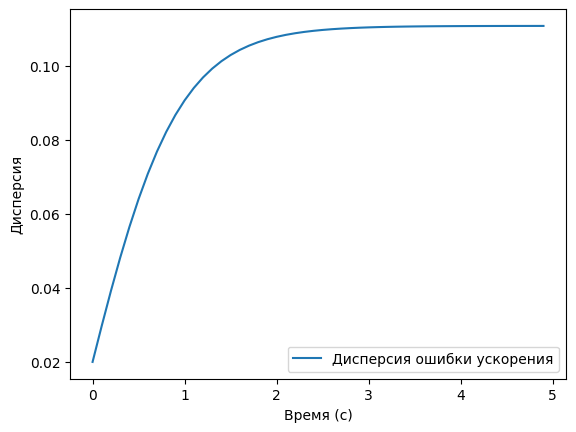

In [ ]:
speed_variance = [P[1, 1] for P in stateCovarianceHistory]
loc_var = [P[0, 0] for P in stateCovarianceHistory]
aceler_var = [P[2, 2] for P in stateCovarianceHistory]

pl.plot(time, loc_var, label="Дисперсия ошибки положения")
pl.xlabel("Время (с)")
pl.ylabel("Дисперсия")
pl.legend()
pl.show()

pl.plot(time, speed_variance, label="Дисперсия ошибки скорости")
pl.xlabel("Время (с)")
pl.ylabel("Дисперсия")
pl.legend()
pl.show()

pl.plot(time, aceler_var, label="Дисперсия ошибки ускорения")
pl.xlabel("Время (с)")
pl.ylabel("Дисперсия")
pl.legend()
pl.show()

In [ ]:
y_learning = y_model[:n-n_test, :]
y_testing = y_model[n-n_test:, :]
x_learning = np.array([i*0.1 for i in range(n-n_test)])
x_testing = np.array([i*0.1 for i in range(n-n_test, n)])

# Чужой фильтр

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

dt = 0.1  # Временной шаг
num_samples = 101  # Количество шагов

# Генерация истинной траектории
true_trajectory = np.zeros((3, num_samples))
measurements_position = np.zeros(num_samples)
measurements_velocity = np.zeros(num_samples)
measurements_acceleration = np.zeros(num_samples)

# Установим ускорение равным 1 с самого начала
true_trajectory[2, :] = 1  # Истинное ускорение (постоянное)
measurements_acceleration[0] = 1  # Начальное измеренное ускорение

for t in range(1, num_samples):
    true_trajectory[0, t] = true_trajectory[0, t-1] + true_trajectory[1, t-1] * dt + 0.5 * true_trajectory[2, t-1] * (dt ** 2)
    true_trajectory[1, t] = true_trajectory[1, t-1] + true_trajectory[2, t-1] * dt  # Истинная скорость

    # Генерация измерений с шумом
    noise_position = np.random.normal(0, 0.1)  # Шум для положения
    noise_velocity = np.random.normal(0, 0.1)  # Шум для скорости
    noise_acceleration = np.random.normal(0, 0.1)  # Шум для ускорения
    measurements_position[t] = true_trajectory[0, t] + noise_position  # Положение с шумом
    measurements_velocity[t] = true_trajectory[1, t] + noise_velocity  # Скорость с шумом
    measurements_acceleration[t] = true_trajectory[2, t] + noise_acceleration  # Ускорение с шумом

    # Выводим значения
    print(f"Итерация {t}: Шум положения = {noise_position:.4f}, Измеренное положение = {measurements_position[t]:.4f}, "
          f"Шум скорости = {noise_velocity:.4f}, Измеренная скорость = {measurements_velocity[t]:.4f}, "
          f"Шум ускорения = {noise_acceleration:.4f}, Измеренное ускорение = {measurements_acceleration[t]:.4f}")


Итерация 1: Шум положения = -0.0932, Измеренное положение = -0.0882, Шум скорости = -0.0251, Измеренная скорость = 0.0749, Шум ускорения = -0.0092, Измеренное ускорение = 0.9908
Итерация 2: Шум положения = -0.2735, Измеренное положение = -0.2535, Шум скорости = -0.1596, Измеренная скорость = 0.0404, Шум ускорения = -0.0665, Измеренное ускорение = 0.9335
Итерация 3: Шум положения = 0.1157, Измеренное положение = 0.1607, Шум скорости = 0.1312, Измеренная скорость = 0.4312, Шум ускорения = -0.1226, Измеренное ускорение = 0.8774
Итерация 4: Шум положения = -0.0232, Измеренное положение = 0.0568, Шум скорости = 0.0441, Измеренная скорость = 0.4441, Шум ускорения = 0.0218, Измеренное ускорение = 1.0218
Итерация 5: Шум положения = -0.0055, Измеренное положение = 0.1195, Шум скорости = -0.1074, Измеренная скорость = 0.3926, Шум ускорения = 0.2036, Измеренное ускорение = 1.2036
Итерация 6: Шум положения = 0.0245, Измеренное положение = 0.2045, Шум скорости = -0.1445, Измеренная скорость = 0.455

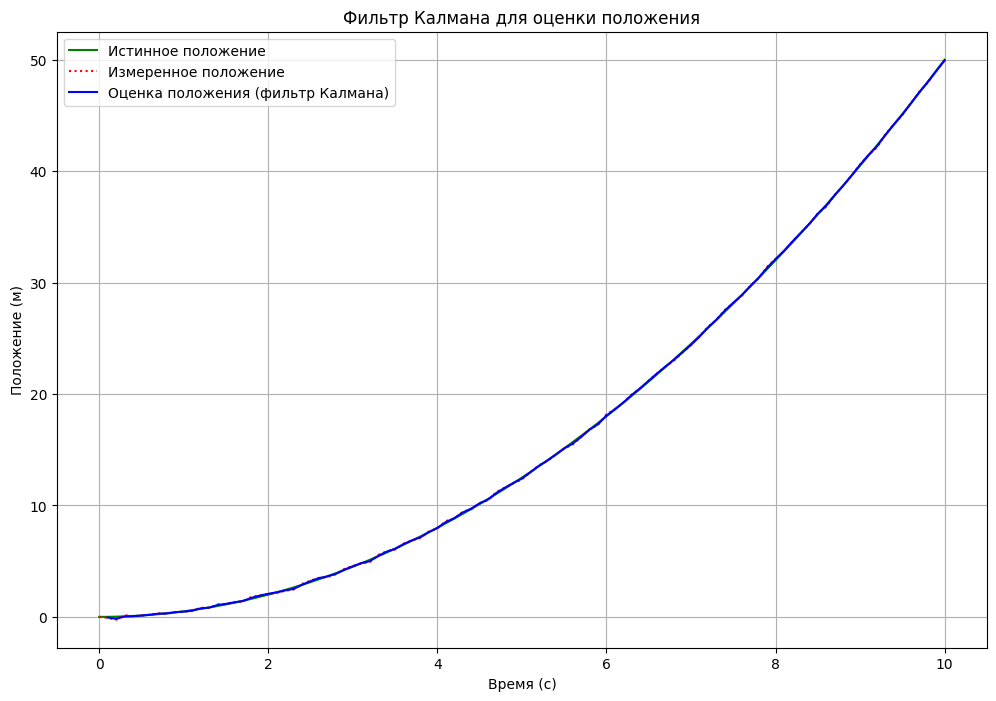

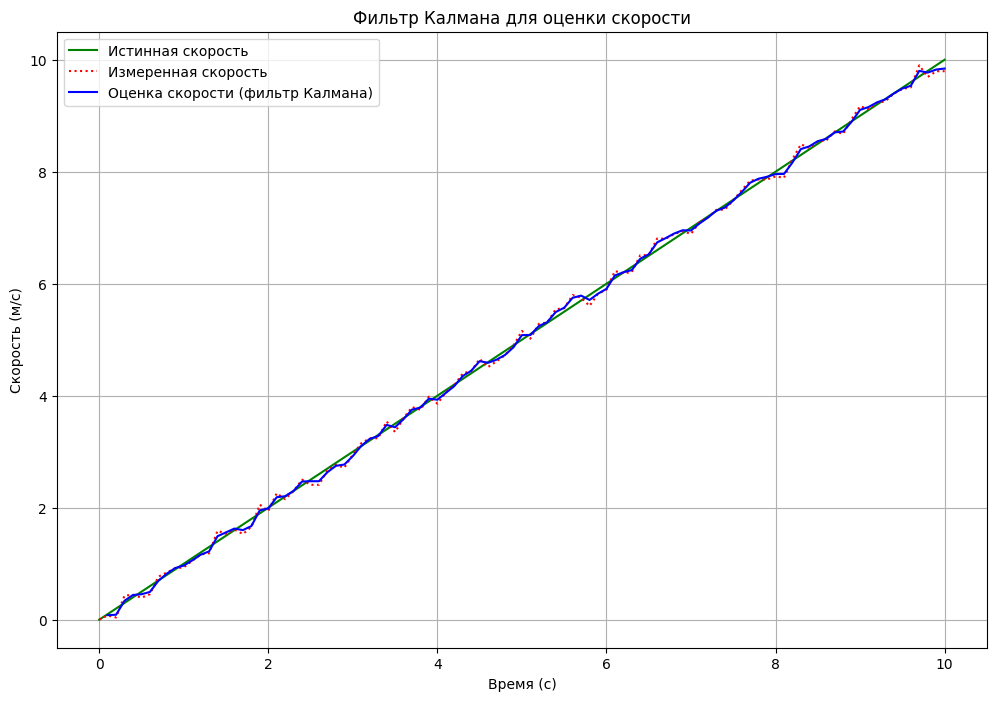

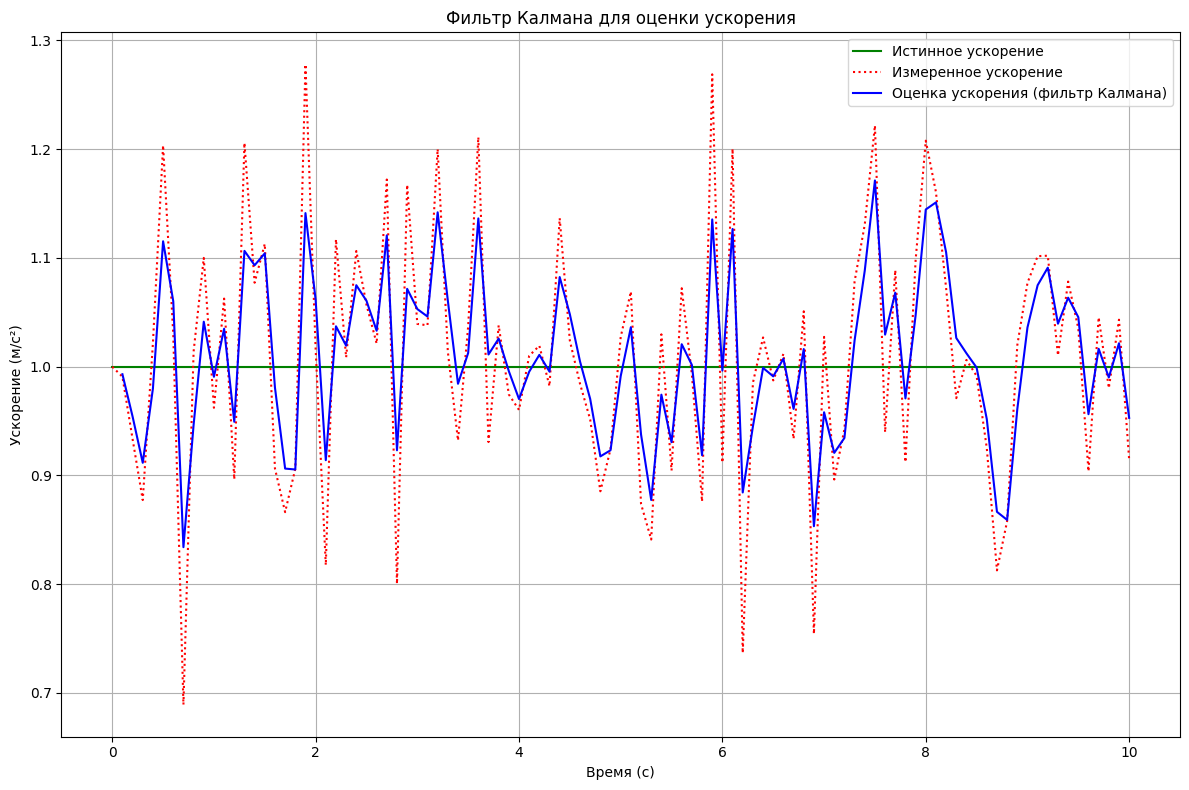

In [ ]:
#Начальные условия
x = np.array([0.0, 0.0, 1.0])  # Начальное состояние [положение, скорость, ускорение]
P = np.eye(3) * 0.01  # Начальная ковариационная матрица

# Определяем матрицы
F = np.array([[1, 0.1, 0.005],
              [0,   1,   0.1],
              [0,   0,    1]])

H_position = np.array([[1, 0, 0]])  # измеряем только положение
H_velocity = np.array([[0, 1, 0]])  # измеряем только скорость
H_acceleration = np.array([[0, 0, 1]])  # измеряем только ускорение

# Ковариационная матрица процесса (Q)
Q = np.array([[0.01, 0, 0],
              [0, 0.01, 0],
              [0, 0, 0.01]])

# Ковариационная матрица измерений (R)
R_position = np.array([[0.01]])  # Шум измерений положения
R_velocity = np.array([[0.01]])  # Шум измерений скорости
R_acceleration = np.array([[0.01]])  # Шум измерений ускорения

# Списки для хранения отфильтрованных значений
filtered_state = []

# Обработка данных
for t in range(1, num_samples):
   # Этап предсказания
    x = F @ x  # Предсказание состояния
    P = F @ P @ F.T + Q  # Предсказание ковариационной матрицы

    # Обновление с измерением положения
    if t < len(measurements_position):
        E_position = measurements_position[t] - H_position @ x  # Остаток для положения
        B_position = H_position @ P @ H_position.T + R_position  # Ковариация остатка
        K_position = P @ H_position.T @ np.linalg.inv(B_position)  # Матрица Калмана для положения

        # Обновление состояния
        x = x + K_position @ E_position  # Обновленное состояние
        P = (np.eye(len(P)) - K_position @ H_position) @ P  # Обновленная ковариационная матрица

    # Обновление с измерением скорости
    if t < len(measurements_velocity):
        E_velocity = measurements_velocity[t] - H_velocity @ x  # Остаток для скорости
        B_velocity = H_velocity @ P @ H_velocity.T + R_velocity  # Ковариация остатка
        K_velocity = P @ H_velocity.T @ np.linalg.inv(B_velocity)  # Матрица Калмана для скорости

         # Обновление с измерением ускорения
    if t < len(measurements_acceleration):
        E_acceleration = measurements_acceleration[t] - H_acceleration @ x  # Остаток для ускорения
        B_acceleration = H_acceleration @ P @ H_acceleration.T + R_acceleration  # Ковариация остатка
        K_acceleration = P @ H_acceleration.T @ np.linalg.inv(B_acceleration)  # Матрица Калмана для ускорения
        x = x + K_acceleration @ E_acceleration  # Обновление состояния
        P = (np.eye(len(P)) - K_acceleration @ H_acceleration) @ P  # Обновленная ковариационная матрица

# Обновление состояния
        x = x + K_velocity @ E_velocity  # Обновленное состояние
        P = (np.eye(len(P)) - K_velocity @ H_velocity) @ P  # Обновленная ковариационная матрица

    filtered_state.append(x.copy())  # Сохранение состояния фильтра Калмана в список

    #Выводим предсказанные значения на каждой итерации
    print(f"Итерация {t}: Положение = {x[0]:.4f}, Скорость = {x[1]:.4f}, Ускорение = {x[2]:.4f}")  # x[0] — положение, x[1] — скорость, x[2] — ускорение

# Преобразуем список в массив
filtered_state = np.array(filtered_state)





# Визуализация
plt.figure(figsize=(12, 8))

time = np.arange(num_samples) * dt
plt.plot(time, true_trajectory[0], label="Истинное положение", color="green")
plt.plot(time, measurements_position, label="Измеренное положение", color="red", linestyle="dotted")
plt.plot(time[1:], filtered_state[:, 0], label="Оценка положения (фильтр Калмана)", color="blue")
plt.title("Фильтр Калмана для оценки положения")
plt.xlabel("Время (с)")
plt.ylabel("Положение (м)")
plt.legend()
plt.grid()

# Визуализация
plt.figure(figsize=(12, 8))
plt.plot(time, true_trajectory[1], label="Истинная скорость", color="green")
plt.plot(time, measurements_velocity, label="Измеренная скорость", color="red", linestyle="dotted")
plt.plot(time[1:], filtered_state[:, 1], label="Оценка скорости (фильтр Калмана)", color="blue")
plt.title("Фильтр Калмана для оценки скорости")
plt.xlabel("Время (с)")
plt.ylabel("Скорость (м/с)")
plt.legend()
plt.grid()

# Визуализация
plt.figure(figsize=(12, 8))
plt.plot(time, true_trajectory[2], label="Истинное ускорение", color="green")
plt.plot(time, measurements_acceleration, label="Измеренное ускорение", color="red", linestyle="dotted")
plt.plot(time[1:], filtered_state[:, 2], label="Оценка ускорения (фильтр Калмана)", color="blue")
plt.title("Фильтр Калмана для оценки ускорения")
plt.xlabel("Время (с)")
plt.ylabel("Ускорение (м/с²)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

#Подготовка данных к ENN

In [ ]:
state_FK200 = filteredState[:200]
state_FK100 = filteredState[200:]

x_learning = np.reshape(x_learning, (n-n_test, 1))
x_testing = np.reshape(x_testing, (n_test, 1))

In [ ]:
import torch
import torch.nn as nn

In [ ]:
#переводим в тензоры
xt_learn= torch.from_numpy(x_learning).float()
xt_test = torch.from_numpy(x_testing).float()
state_fk200 = torch.from_numpy(state_FK200).float() #тензор
state_fk100 = torch.from_numpy(state_FK100).float() #тензор


In [ ]:
# Define the network parameters
input_size = 1
hidden_size = 3
num_layers = 1
num_classes = 1

#Разные ENN

In [ ]:
class ElmanRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(ElmanRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, bias = False)# batch_first=True) #batch_first=True,
        #self.fc = nn.Linear(hidden_size, num_classes, bias = False)

    def forward(self, x):
        state0 = torch.zeros(self.num_layers, self.hidden_size) #####
        out_1layer, last_state = self.rnn(x, state0)
        #out_2layer = self.fc(out_1layer)
        return out_1layer #, out_2layer

In [ ]:
# Create the network
model = ElmanRNN(input_size, hidden_size, num_layers, num_classes)
# Define the loss function and optimization algorithm
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.04)

outputs_y = torch.zeros(y_learning.shape).float()  # Явно преобразуем к float32
state_nn200 = torch.zeros(state_fk200.shape).float()  # Явно преобразуем к float32
targets = np.tanh(state_fk200)

count_epoch = 200
# Train the network on the data
for epoch in range(count_epoch):
    # Get the inputs and targets
    inputs = xt_learn
    #targets = np.tanh(state_fk200)

    # Forward pass
    state_nn200  = model(inputs)
    #state_nn200 = state_nn200.float()

    loss = criterion(state_nn200, targets) ######

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward() #############
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{count_epoch}], Loss: {loss.item():.4f}')

Epoch [10/200], Loss: 0.0252
Epoch [20/200], Loss: 0.0201
Epoch [30/200], Loss: 0.0208
Epoch [40/200], Loss: 0.0204
Epoch [50/200], Loss: 0.0195
Epoch [60/200], Loss: 0.0186
Epoch [70/200], Loss: 0.0182
Epoch [80/200], Loss: 0.0180
Epoch [90/200], Loss: 0.0180
Epoch [100/200], Loss: 0.0178
Epoch [110/200], Loss: 0.0177
Epoch [120/200], Loss: 0.0175
Epoch [130/200], Loss: 0.0172
Epoch [140/200], Loss: 0.0167
Epoch [150/200], Loss: 0.0157
Epoch [160/200], Loss: 0.0131
Epoch [170/200], Loss: 0.0097
Epoch [180/200], Loss: 0.0073
Epoch [190/200], Loss: 0.0065
Epoch [200/200], Loss: 0.0063


In [ ]:
np_state_nn = state_nn200.detach().numpy()
np_state_fk = targets.detach().numpy()

In [ ]:
def arc_tanh(x):
  out= 0.5*(np.log(np.divide(x+1, 1-x)))
  return out

In [ ]:
arc_state_nn = arc_tanh(np_state_nn)

<ipython-input-27-833ddabe9f58>:2: RuntimeWarning: divide by zero encountered in divide
  out= 0.5*(np.log(np.divide(x+1, 1-x)))


In [ ]:
np_state_nn[150]

array([0.9999249, 0.9999998, 0.7762324], dtype=float32)

<ipython-input-27-833ddabe9f58>:2: RuntimeWarning: divide by zero encountered in divide
  out= 0.5*(np.log(np.divide(x+1, 1-x)))


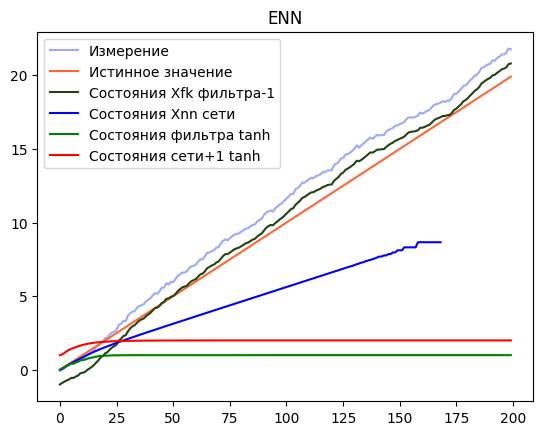

In [ ]:
# Визуализация
pl.title("ENN")
pl.plot(y_learning, label="Измерение", color="#99AAFF")
pl.plot(x_learning, label="Истинное значение", color="#FF6633")

pl.plot(filteredState[:200, 1]-1, label="Состояния Xfk фильтра-1", color="#224411")
pl.plot(arc_tanh(np_state_nn[:200,1]), label="Состояния Xnn сети", color="b")

pl.plot(np_state_fk[:200,1], label="Состояния фильтра tanh ", color="g")
pl.plot(np_state_nn[:200,1]+1, label="Состояния сети+1 tanh", color="r")
pl.legend()
pl.show()

In [ ]:
# Получение весов
weights_input_to_hidden = model.rnn.weight_ih_l0.data.numpy()  # Веса "вход-скрытый" для первого слоя
weights_hidden_to_hidden = model.rnn.weight_hh_l0.data.numpy()  # Веса "скрытый-скрытый" для первого слоя

print("Weights from input to hidden layer:")
print(weights_input_to_hidden)

print("\nWeights from hidden layer to hidden layer:")
print(weights_hidden_to_hidden)


Weights from input to hidden layer:
[[ 0.2983543 ]
 [ 0.4918896 ]
 [-0.02905095]]

Weights from hidden layer to hidden layer:
[[ 0.08813436  0.5404587  -0.01102075]
 [ 0.3419839   0.8199126  -0.5513714 ]
 [ 0.5857767   0.93912923 -0.08730743]]


<ipython-input-174-833ddabe9f58>:2: RuntimeWarning: divide by zero encountered in divide
  out= 0.5*(np.log(np.divide(x+1, 1-x)))


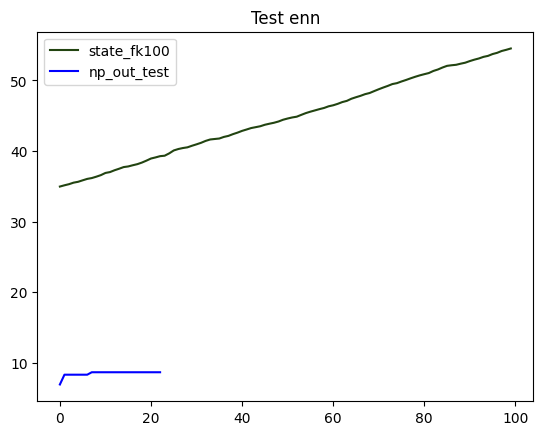

In [ ]:
outputs_test = model(xt_test)
loss = criterion(outputs_test, state_fk100)

np_out_test = outputs_test.detach().numpy()
pl.title("Test enn")
pl.plot(state_fk100[:200, 1], label="state_fk100", color="#224411")
pl.plot(arc_tanh(np_out_test[:200, 1]), label="np_out_test", color="b")
pl.legend()
pl.show()
#Вывод: ENN плохо предсказывает значения за пределами обучающего диапазона